<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [ ]:
import requests
import zipfile
import io
import pandas as pd

# Ссылка на архив
url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

# 1. Скачиваем ZIP-файл
response = requests.get(url, verify=False)

# 2. Распаковываем его "на лету" без сохранения во временный файл
with zipfile.ZipFile(io.BytesIO(response.content)) as zfile:
    # Извлекаем все файлы в текущую папку
    zfile.extractall()

# 3. Читаем Excel-файл в pandas DataFrame
data = pd.read_excel("online_retail_II.xlsx")  # принимает локальный путь к Excel
data.head()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'archive.ics.uci.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
data.isnull().sum() #как мы видим, куча пропусков в описании товара и ид покупателей

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
print('Общий объём продаж: ', data['Quantity'].sum())

Общий объём продаж:  5432041


In [ ]:
data['StockCode'].nunique()
data['StockCode'].unique()
data['StockCode'] = data['StockCode'].astype(str)

data['Revenue'] = data['Price'] * data['Quantity']
revenue_by_product = data.groupby('StockCode')['Revenue'].sum()
revenue_by_product = revenue_by_product.sort_values(ascending=False)
total = revenue_by_product.sum()
revenue_df = revenue_by_product.reset_index()
revenue_df.columns = ['StockCode', 'Total_Revenue']
display(revenue_df) #есть отрицательная выручка, тк есть возврат товаров, в столбце Quantity минусов довольно много

,StockCode,Total_Revenue
0,22423,163051.46
1,85123A,155825.52
2,DOT,116401.99
3,85099B,88922.48
4,84879,72454.12
...,...,...
4627,D,-7788.32
4628,M,-14122.13
4629,BANK CHARGES,-28386.99
4630,AMAZONFEE,-39243.08


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [ ]:
tab_info = pd.DataFrame(data.dtypes, columns=['column type']).T

# Создаем DataFrame с суммарным количеством пропущенных значений по столбцам (null values (nb)),
# и также транспонируем таблицу, чтобы столбцы стали строками.
null_values_nb = pd.DataFrame(data.isnull().sum(), columns=['null values (nb)']).T

# Аналогично создаем DataFrame с процентным соотношением пропусков от общего числа строк,
# умножаем на 100, округляем до двух знаков после запятой (round(2)),
# и транспонируем, чтобы получить удобный формат.
null_values_percent = (
    pd.DataFrame(data.isnull().sum() / data.shape[0] * 100, columns=['null values (%)'])
    .round(2)
    .T
)

# Конкатенируем все три таблицы (типы столбцов, кол-во пропусков, процент пропусков)
# в один общий DataFrame "tab_info" для удобного отображения всей информации.
tab_info = pd.concat([tab_info, null_values_nb, null_values_percent])

# Отображаем полученную информацию о наборе данных.
display(tab_info)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
column type,object,object,object,int64,datetime64[ns],float64,float64,object,float64
null values (nb),0,0,2928,0,0,0,107927,0,0
null values (%),0.0,0.0,0.56,0.0,0.0,0.0,20.54,0.0,0.0


In [ ]:
#удаляем пустые строки

data1 = data.dropna(subset=['Customer ID']) # Удаляем строки с пропусками
print('Осталось строк в таблице:', data1.shape[0])

Осталось строк в таблице: 417534


In [ ]:
data1 = data1[data1['Price'] > 0]     # убираем нулевые/отрицательные цены
data1['Revenue'] = data1['Quantity'] * data1['Price']

print(f"Записей после очистки: {len(data1)}")

Записей после очистки: 417503


In [ ]:
#обработка дубликатов (было в теории, датасет огромный, лучше что-то выкинуть)

print(f"Количество полностью дублированных записей: {data1.duplicated().value_counts()}")

# Удаляем дубликаты из датафрейма
data1.drop_duplicates(inplace=True)

# Выводим оставшееся количество строк
print(f"Осталось {data1.shape[0]} строк")

Количество полностью дублированных записей: False    410732
True       6771
Name: count, dtype: int64
Осталось 410732 строк


In [ ]:
# Шаг 1: Фильтруем записи, в которых Quantity < 0
negative_quantity = data1[data1['Quantity'] < 0]

# Шаг 2: Выводим количество таких записей с помощью f-строки
print(f"Количество записей с отрицательным числом: {negative_quantity.shape[0]}")

# Шаг 3: Выводим первые 5 записей из отфильтрованного датафрейма
negative_quantity.head()

Количество записей с отрицательным числом: 9816


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4


In [ ]:
#проверяем, что тут только возвраты, а не какие-то странные данные

cnt=0
for str_ in negative_quantity['Invoice']:
    if str_[0]!='C':
        cnt+=1
print('Количество транзакций, не содержащих признак возврата:', cnt)

Количество транзакций, не содержащих признак возврата: 0


In [ ]:
cnt = sum(1 for inv_no in negative_quantity['Invoice'] if inv_no[0] != 'C')

# Выводим результат
print(f"Количество транзакций, не содержащих признак возврата: {cnt}")

Количество транзакций, не содержащих признак возврата: 0


In [ ]:
negative_quantity['Invoice'].apply(lambda x: 'C' not in x).sum()

np.int64(0)

In [ ]:
# Группируем по клиенту и номеру заказа и считаем число уникальных товаров
nb_products_per_basket = data1.groupby(['Customer ID', 'Invoice'])['StockCode'].nunique().reset_index()

# Переименовываем столбец с количеством уникальных товаров
nb_products_per_basket.rename(columns={'StockCode': 'Number of unique products'}, inplace=True)

# Смотрим первые 5 строк
nb_products_per_basket.head()

,Customer ID,Invoice,Number of unique products
0,12346.0,491725,1
1,12346.0,491742,1
2,12346.0,491744,1
3,12346.0,492718,1
4,12346.0,492722,1


In [ ]:
# Преобразуем столбец 'Invoice' в строку
nb_products_per_basket['Invoice'] = nb_products_per_basket['Invoice'].astype(str)

# Создаём признак возврата: 1, если InvoiceNo начинается с 'C', иначе 0
nb_products_per_basket['order_canceled'] = nb_products_per_basket['Invoice'].str.startswith('C').astype(int)

# Считаем процент возвратов (целое число) и выводим
percent_canceled = int(nb_products_per_basket['order_canceled'].mean() * 100)
print(f"Процент возвратов: {percent_canceled}%")

Процент возвратов: 18%


In [ ]:
nb_products_per_basket[nb_products_per_basket['order_canceled']==1].head()

,Customer ID,Invoice,Number of unique products,order_canceled
11,12346.0,C495800,1,1
12,12346.0,C514024,1,1
13,12346.0,C525099,1,1
14,12346.0,C525274,1,1
21,12349.0,C490283,5,1


In [ ]:
data1[data1['Customer ID']==12352] #странная история покупок

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
453366,532430,85152,HAND OVER THE CHOCOLATE SIGN,12,2010-11-12 10:20:00,2.10,12352.0,Norway,25.20
453367,532430,21166,COOK WITH WINE METAL SIGN,12,2010-11-12 10:20:00,1.95,12352.0,Norway,23.40
453368,532430,22668,PINK BABY BUNTING,5,2010-11-12 10:20:00,2.95,12352.0,Norway,14.75
453369,532430,21121,SET/10 RED POLKADOT PARTY CANDLES,24,2010-11-12 10:20:00,1.25,12352.0,Norway,30.00
453370,532430,82583,HOT BATHS METAL SIGN,12,2010-11-12 10:20:00,2.10,12352.0,Norway,25.20
453371,532430,21175,GIN + TONIC DIET METAL SIGN,12,2010-11-12 10:20:00,2.10,12352.0,Norway,25.20
497242,535838,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,12,2010-11-29 10:07:00,0.95,12352.0,Norway,11.40
497243,535838,22423,REGENCY CAKESTAND 3 TIER,1,2010-11-29 10:07:00,12.75,12352.0,Norway,12.75
497244,535838,22198,LARGE POPCORN HOLDER,12,2010-11-29 10:07:00,1.65,12352.0,Norway,19.80
497245,535838,22197,SMALL POPCORN HOLDER,12,2010-11-29 10:07:00,0.85,12352.0,Norway,10.20


In [ ]:
data_cleaned = data1[data1['Quantity'] > 0].copy()
print(data_cleaned.shape[0])

400916


In [ ]:
zero_price_count = (data_cleaned['Price'] == 0).sum() # 33
print("Количество транзакций с нулевой ценой за единицу товара:", zero_price_count)

data_cleaned = data_cleaned[data_cleaned['Price'] != 0]

print("Количество записей после удаления нулевых цен:", data_cleaned.shape[0])

Количество транзакций с нулевой ценой за единицу товара: 0
Количество записей после удаления нулевых цен: 400916


In [ ]:
def get_quantity_canceled(data):
    """
    Функция проходит по всем транзакциям-возвратам в рамках каждой группы
    (CustomerID, StockCode) и ищет покупку (или покупки) с более ранней датой
    и подходящим количеством товара. В результате возвращает Series, где
    для каждой «положительной» записи (покупки) указывается, сколько товаров
    вернули позднее.
    """
    # Создаём результирующий столбец, заполненный нулями
    quantity_canceled = pd.Series(0, index=data.index, dtype=int)

    # Разбиваем таблицу на группы по клиенту и коду товара
    grouped = data.groupby(['Customer ID', 'StockCode'], group_keys=False)

    def process_group(df_group):
        # Сортируем текущую группу по дате
        df_group = df_group.sort_values('InvoiceDate')

        # Отбираем положительные (покупки) и отрицательные (возвраты) записи
        positives = df_group[df_group['Quantity'] > 0]
        negatives = df_group[df_group['Quantity'] < 0]

        for neg_idx, neg_row in negatives.iterrows():
            # Ищем те покупки, что идут раньше по дате
            candidates = positives[positives['InvoiceDate'] < neg_row['InvoiceDate']]
            if candidates.empty:
                continue

            # Если ровно одна запись подходит, сразу сохраняем результат
            if len(candidates) == 1:
                quantity_canceled.at[candidates.index[0]] = -neg_row['Quantity']
            else:
                # Несколько возможных покупок: сортируем их в обратном порядке индексов (или дат)
                candidates = candidates.sort_index(ascending=False)
                # Ищем первую, где Quantity >= нужного объёма возврата
                for pos_idx, pos_row in candidates.iterrows():
                    if pos_row['Quantity'] >= -neg_row['Quantity']:
                        quantity_canceled.at[pos_idx] = -neg_row['Quantity']
                        break

        return df_group

    # Применяем функцию к каждой группе
    grouped.apply(process_group)

    return quantity_canceled

# Пример использования
quantity_canceled = get_quantity_canceled(data)

/tmp/ipykernel_1760/621507648.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(process_group)


In [ ]:
quantity_canceled

,0
0,0
1,0
2,0
3,0
4,0
...,...
525456,0
525457,0
525458,0
525459,0


In [ ]:
data1['QuantityCanceled'] = quantity_canceled

In [ ]:
data_cleaned = data1[data1['Quantity'] > 0].copy()
print(data_cleaned.shape[0])

400916


In [ ]:
data_positive_quantity = data_cleaned[data_cleaned['QuantityCanceled'] == 0]

In [ ]:
zero_price_count = (data_cleaned['Price'] == 0).sum() # 33
print("Количество транзакций с нулевой ценой за единицу товара:", zero_price_count)

# 2) Удаляем такие транзакции из таблицы
data_cleaned = data_cleaned[data_cleaned['Price'] != 0]

# 3) Узнаём, сколько записей осталось
print("Количество записей после удаления нулевых цен:", data_cleaned.shape[0])

Количество транзакций с нулевой ценой за единицу товара: 0
Количество записей после удаления нулевых цен: 400916


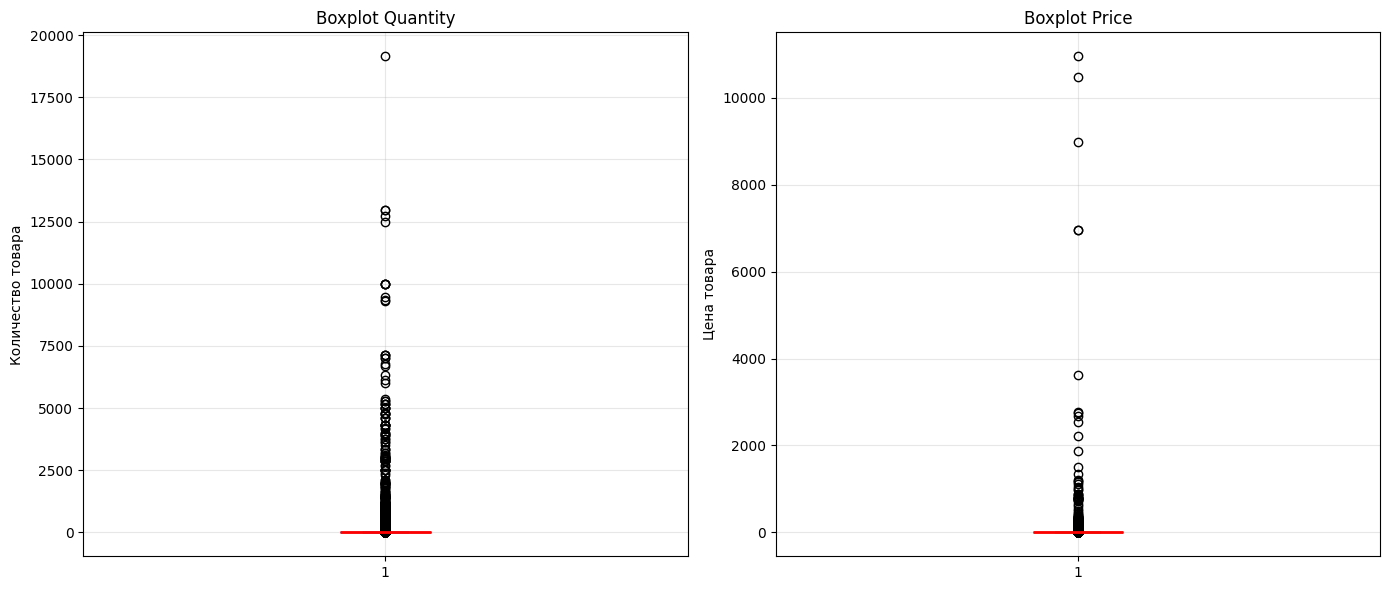

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot для Quantity
axes[0].boxplot(data_cleaned['Quantity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot Quantity')
axes[0].set_ylabel('Количество товара')
axes[0].grid(True, alpha=0.3)

# Boxplot для Price
axes[1].boxplot(data_cleaned['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                whiskerprops=dict(color='darkgreen'),
                capprops=dict(color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Price')
axes[1].set_ylabel('Цена товара')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Контрольная дата (на один день превышает последнюю дату в данных)
now = pd.to_datetime("2011-12-10")

data_cleaned['TotalPrice'] = data_cleaned['Price'] * (
    data_cleaned['Quantity'] - data_cleaned['QuantityCanceled']
)

# Настраиваем агрегацию для RFM-параметров
custom_aggregation = {
    "InvoiceDate": lambda x: (now - x.max()).days,  # Recency
    "Invoice": lambda x: x.nunique(),            # Frequency
    "TotalPrice": "sum",                           # Monetary
}

# Формируем RFM-таблицу
rfm_table = (
    data_cleaned
    .groupby("Customer ID")
    .agg(custom_aggregation)
    .rename(columns={
        "InvoiceDate": "Recency",
        "Invoice": "Frequency",
        "TotalPrice": "Monetary",
        "TotalQuantity": "MeanQuantity"
    })
)

# Просматриваем первые строки итоговой таблицы
rfm_table.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,529,11,368.36
12347.0,367,2,1323.32
12348.0,438,1,222.16
12349.0,407,3,2671.14
12351.0,375,1,300.93


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# Выбираем столбцы для построения коробчатых диаграмм
columns_to_plot = ["Recency", "Frequency", "Monetary"]

# Создаём коробчатые диаграммы для каждого из выбранных признаков
boxes = [px.box(rfm_table, x=col) for col in columns_to_plot]

# Формируем макет из трёх подположений
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Recency", "Frequency", "Monetary")
)

# Добавляем каждую диаграмму в свой подплот
for i, box_fig in enumerate(boxes):
    fig.add_trace(box_fig.data[0], row=1, col=i+1)

# Настраиваем и выводим итоговую диаграмму
fig.update_layout(showlegend=True)
fig.write_html("boxplot_1.html")
fig.show()

In [ ]:
h_cap_monetary = rfm_table["Monetary"].quantile(0.95)
h_cap_frequency = rfm_table["Frequency"].quantile(0.95)

outliers = rfm_table[
    (rfm_table["Monetary"] > h_cap_monetary) |
    (rfm_table["Frequency"] > h_cap_frequency)
]

rfm_table_cleaned = rfm_table.drop(outliers.index)

print(f"После удаления выбросов осталось {rfm_table_cleaned.shape[0]} клиентов в RFM-таблице.")

После удаления выбросов осталось 4022 клиентов в RFM-таблице.


In [ ]:
from sklearn import pipeline, preprocessing, decomposition

# Создаём конвейер с двумя шагами:
# 1) Стандартизация данных
# 2) Метод главных компонент (2 компоненты)
pipeline_preprocessing = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("dimension", decomposition.PCA(n_components=2))])

# Обучаем конвейер на очищенной RFM-таблице и получаем преобразованные данные
rfm_table_processed = pipeline_preprocessing.fit_transform(rfm_table_cleaned)
rfm_table_processed = pd.DataFrame(
    rfm_table_processed,
    columns=["axis-1", "axis-2"],
    index=rfm_table_cleaned.index
)

# Узнаём, какую долю дисперсии объясняет первая главная компонента
explained_variance_first = pipeline_preprocessing["dimension"].explained_variance_ratio_[0]
print(f"Первая главная компонента объясняет {round(explained_variance_first, 2)} доли дисперсии.")

Первая главная компонента объясняет 0.67 доли дисперсии.


#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

In [ ]:
import plotly.express as px
from sklearn import cluster, metrics

# Перебираем числе кластеров от 2 до 10
n_clusters_list = list(range(2, 11))
silhouette_scores = []

for n_clusters in n_clusters_list:
    kmeans = cluster.KMeans(init="k-means++", n_clusters=n_clusters, random_state=42)
    kmeans.fit(rfm_table_processed)
    clusters = kmeans.predict(rfm_table_processed)

    # Считаем коэффициент силуэта
    silhouette_avg = metrics.silhouette_score(rfm_table_processed, clusters)
    silhouette_scores.append(silhouette_avg)

# Формируем DataFrame с количеством кластеров и соответствующими коэффициентами силуэта
silhouette_df = pd.DataFrame({
    "n_clusters": n_clusters_list,
    "silhouette_score": silhouette_scores
})

# Строим линию зависимости коэффициента силуэта от числа кластеров
fig = px.line(
    silhouette_df,
    x="n_clusters",
    y="silhouette_score",
    title="Зависимость коэффициента силуэта от числа кластеров (k-means)"
)
fig.show()

# Находим оптимальное число кластеров и максимальный коэффициент силуэта
best_index = silhouette_df["silhouette_score"].idxmax()
best_n_clusters = silhouette_df.loc[best_index, "n_clusters"]
max_silhouette = round(silhouette_df.loc[best_index, "silhouette_score"], 2)

print(f"1) Оптимальное количество кластеров: {best_n_clusters}")
print(f"2) Максимальное значение коэффициента силуэта: {max_silhouette}")

1) Оптимальное количество кластеров: 3
2) Максимальное значение коэффициента силуэта: 0.52


In [ ]:
from sklearn import cluster

# Создаём и обучаем модель K-Means с оптимальным числом кластеров
model = cluster.KMeans(init="k-means++", n_clusters=3, random_state=42)
model.fit(rfm_table_processed)

KMeans(n_clusters=3, random_state=42)

In [ ]:
model4 = cluster.KMeans(init="k-means++", n_clusters=4, random_state=42)
model4.fit(rfm_table_processed)

KMeans(n_clusters=4, random_state=42)

In [ ]:
model6 = cluster.KMeans(init="k-means++", n_clusters=6, random_state=42)
model6.fit(rfm_table_processed)

KMeans(n_clusters=6, random_state=42)

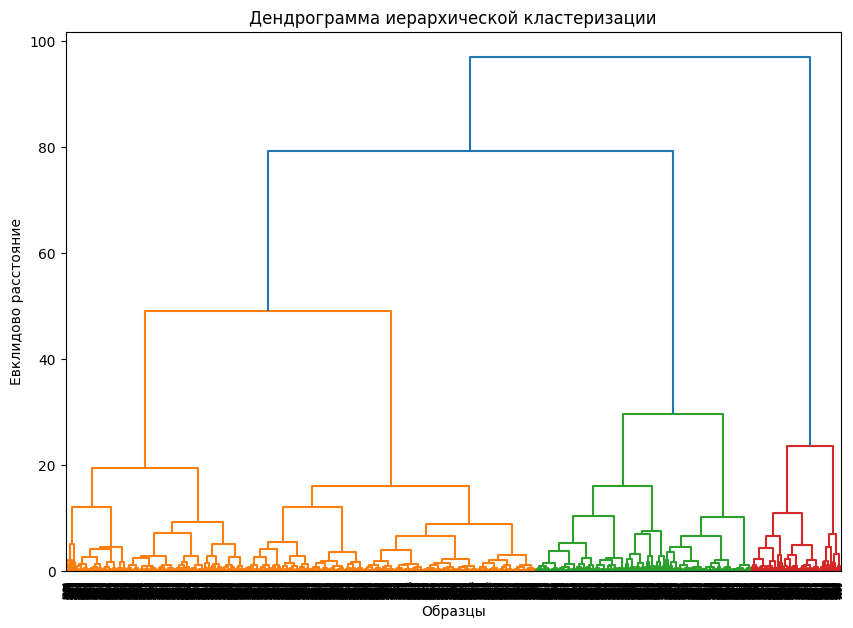

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
linked = linkage(rfm_table_processed, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Образцы')
plt.ylabel('Евклидово расстояние')
plt.show()

# Применение иерархической кластеризации с исправлением параметра
n_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(rfm_table_processed)


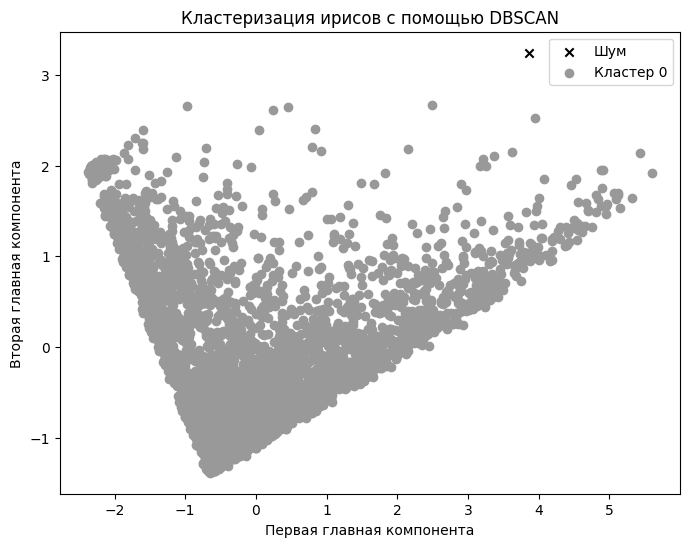

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=0.62, min_samples=3)  # параметры могут быть настроены
dbscan_labels = dbscan.fit_predict(rfm_table_processed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(rfm_table_processed)

# Визуализация результатов кластеризации DBSCAN
plt.figure(figsize=(8, 6))
unique_labels = np.unique(dbscan_labels)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for color, label in zip(colors, unique_labels):
    if label == -1:
        # Шумовые точки
        color = 'k'
        marker = 'x'
        label_text = 'Шум'
    else:
        marker = 'o'
        label_text = f'Кластер {label}'
    plt.scatter(X_pca[dbscan_labels == label, 0],
                X_pca[dbscan_labels == label, 1],
                c=[color],
                marker=marker,
                label=label_text)
plt.title('Кластеризация ирисов с помощью DBSCAN')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.show()

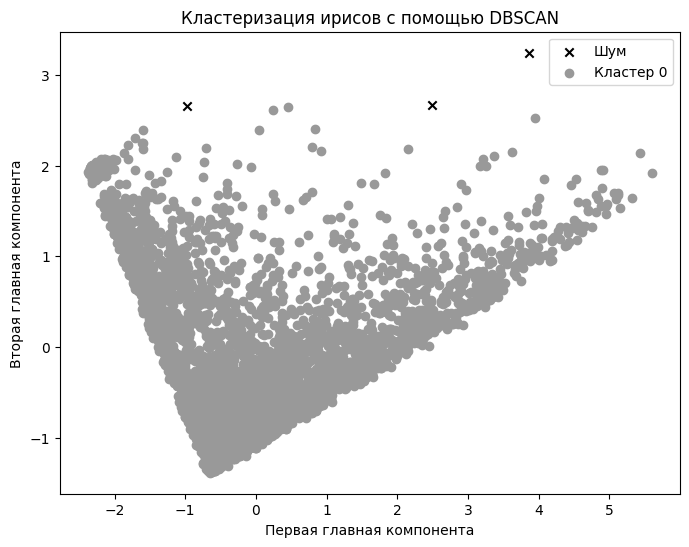

In [ ]:
dbscan52 = DBSCAN(eps=0.52, min_samples=3)  # параметры могут быть настроены
dbscan_labels52 = dbscan52.fit_predict(rfm_table_processed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(rfm_table_processed)

# Визуализация результатов кластеризации DBSCAN
plt.figure(figsize=(8, 6))
unique_labels = np.unique(dbscan_labels52)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for color, label in zip(colors, unique_labels):
    if label == -1:
        # Шумовые точки
        color = 'k'
        marker = 'x'
        label_text = 'Шум'
    else:
        marker = 'o'
        label_text = f'Кластер {label}'
    plt.scatter(X_pca[dbscan_labels52 == label, 0],
                X_pca[dbscan_labels52 == label, 1],
                c=[color],
                marker=marker,
                label=label_text)
plt.title('Кластеризация ирисов с помощью DBSCAN')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.show()

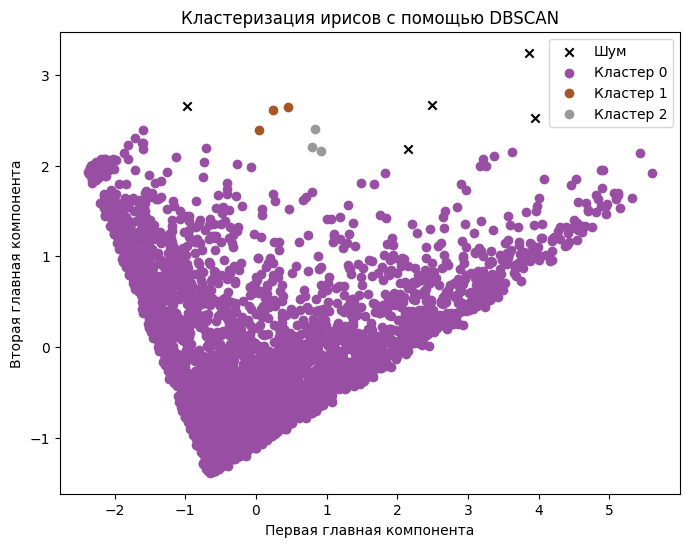

In [ ]:
dbscan42 = DBSCAN(eps=0.42, min_samples=3)  # параметры могут быть настроены
dbscan_labels42 = dbscan42.fit_predict(rfm_table_processed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(rfm_table_processed)

# Визуализация результатов кластеризации DBSCAN
plt.figure(figsize=(8, 6))
unique_labels = np.unique(dbscan_labels42)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for color, label in zip(colors, unique_labels):
    if label == -1:
        # Шумовые точки
        color = 'k'
        marker = 'x'
        label_text = 'Шум'
    else:
        marker = 'o'
        label_text = f'Кластер {label}'
    plt.scatter(X_pca[dbscan_labels42 == label, 0],
                X_pca[dbscan_labels42 == label, 1],
                c=[color],
                marker=marker,
                label=label_text)
plt.title('Кластеризация ирисов с помощью DBSCAN')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.show()

#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

0.47593392246973
4431.236738465204
0.7424997418750111
0.42868737971802423
4302.697863881166
0.8664279889264859
0.3970892185927923
3698.7977127305417
0.9062441574645606
0.4467828693875493
55.98101145475731
1.42543307136658
0.1868133629446196
40.67238235770309
1.686839345429294
0.03506975792921403
28.59284539745191
1.7318981231967032
0.44637642688204077
3669.16736303732
0.7561385515014415
0.39648010934782024
3949.8540221840585
0.8812534511295389
0.3553223735432263
3214.117422201272
1.030298200552951


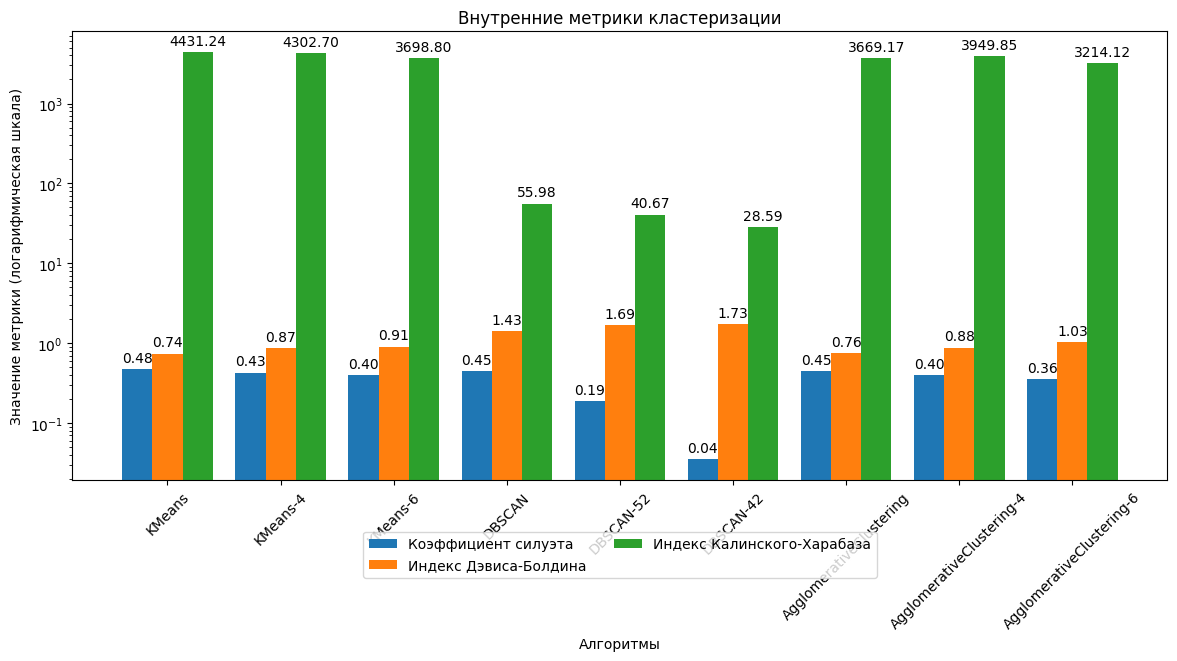

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.spatial.distance import cdist, pdist

scaler = StandardScaler()
rfm_table_processed1 = scaler.fit_transform(rfm_table_cleaned)
results = {}

# Кластеризация с помощью KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(rfm_table_processed1)
results['k-means'] = y_kmeans

kmeans4 = KMeans(n_clusters=4, random_state=42)
y_kmeans4 = kmeans4.fit_predict(rfm_table_processed1)
results['k-means-4'] = y_kmeans4

kmeans6 = KMeans(n_clusters=6, random_state=42)
y_kmeans6 = kmeans6.fit_predict(rfm_table_processed1)
results['k-means-6'] = y_kmeans6

# Кластеризация с помощью DBSCAN
dbscan = DBSCAN(eps=0.62, min_samples=3)
y_dbscan = dbscan.fit_predict(rfm_table_processed1)
results['DBSCAN'] = y_dbscan

dbscan52 = DBSCAN(eps=0.52, min_samples=3)
y_dbscan52 = dbscan52.fit_predict(rfm_table_processed1)
results['DBSCAN-52'] = y_dbscan52

dbscan42 = DBSCAN(eps=0.42, min_samples=3)
y_dbscan42 = dbscan42.fit_predict(rfm_table_processed1)
results['DBSCAN-42'] = y_dbscan42

# Кластеризация с помощью агламеративной
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(rfm_table_processed1)
results['AgglomerativeClustering'] = y_hc

hc4 = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_hc4 = hc4.fit_predict(rfm_table_processed1)
results['AgglomerativeClustering-4'] = y_hc4

hc6 = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
y_hc6 = hc6.fit_predict(rfm_table_processed1)
results['AgglomerativeClustering-6'] = y_hc6

# Функции для вычисления метрик
def compute_internal_metrics(X, labels):
    silhouette = silhouette_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    print(silhouette)
    print(calinski_harabasz)
    print(davies_bouldin)
    return {
        'Коэффициент силуэта': silhouette,
        'Индекс Дэвиса-Болдина': davies_bouldin,
        'Индекс Калинского-Харабаза': calinski_harabasz,
    }

# Вычисление метрик для каждого алгоритма
metrics_results = {}

# KMeans
metrics_results['KMeans'] = {}
metrics_results['KMeans']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_kmeans)

metrics_results['KMeans-4'] = {}
metrics_results['KMeans-4']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_kmeans4)

metrics_results['KMeans-6'] = {}
metrics_results['KMeans-6']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_kmeans6)

# DBSCAN
metrics_results['DBSCAN'] = {}
metrics_results['DBSCAN']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_dbscan)

metrics_results['DBSCAN-52'] = {}
metrics_results['DBSCAN-52']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_dbscan52)

metrics_results['DBSCAN-42'] = {}
metrics_results['DBSCAN-42']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_dbscan42)

# AgglomerativeClustering
metrics_results['AgglomerativeClustering'] = {}
metrics_results['AgglomerativeClustering']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_hc)

metrics_results['AgglomerativeClustering-4'] = {}
metrics_results['AgglomerativeClustering-4']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_hc4)

metrics_results['AgglomerativeClustering-6'] = {}
metrics_results['AgglomerativeClustering-6']['Внутренние'] = compute_internal_metrics(rfm_table_processed1, y_hc6)

# Подготовка данных для визуализации
internal_metrics = ['Коэффициент силуэта', 'Индекс Дэвиса-Болдина', 'Индекс Калинского-Харабаза']
algorithms = ['KMeans', 'KMeans-4', 'KMeans-6', 'DBSCAN', 'DBSCAN-52', 'DBSCAN-42', 'AgglomerativeClustering', 'AgglomerativeClustering-4', 'AgglomerativeClustering-6']

# Подготовка данных для графиков
def collect_metrics(metrics_dict, metric_names, metric_type):
    data = {}
    for metric in metric_names:
        values = []
        for algo in algorithms:
            value = metrics_dict[algo][metric_type].get(metric)
            values.append(value)
        data[metric] = values
    return data

internal_data = collect_metrics(metrics_results, internal_metrics, 'Внутренние')

# Функция для построения графиков
def plot_metrics(data, title, is_internal=False):
    x = np.arange(len(algorithms))
    total_width = 0.8  # Общая ширина всех столбцов для одного алгоритма
    num_metrics = len(data)
    width = total_width / num_metrics  # Ширина одного столбца
    offsets = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, num_metrics)

    fig, ax = plt.subplots(figsize=(12, 6))

    for idx, (attribute, measurement) in enumerate(data.items()):
        rects = ax.bar(x + offsets[idx], measurement, width, label=attribute)

        # Добавление меток над столбцами
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom')

    ax.set_xlabel('Алгоритмы')
    ax.set_ylabel('Значение метрики')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, )
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

    # Если это внутренние метрики, используем логарифмический масштаб по оси Y
    if is_internal:
        ax.set_yscale('log')
        ax.set_ylabel('Значение метрики (логарифмическая шкала)')

    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

# Построение графиков
plot_metrics(internal_data, 'Внутренние метрики кластеризации', is_internal=True)

#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



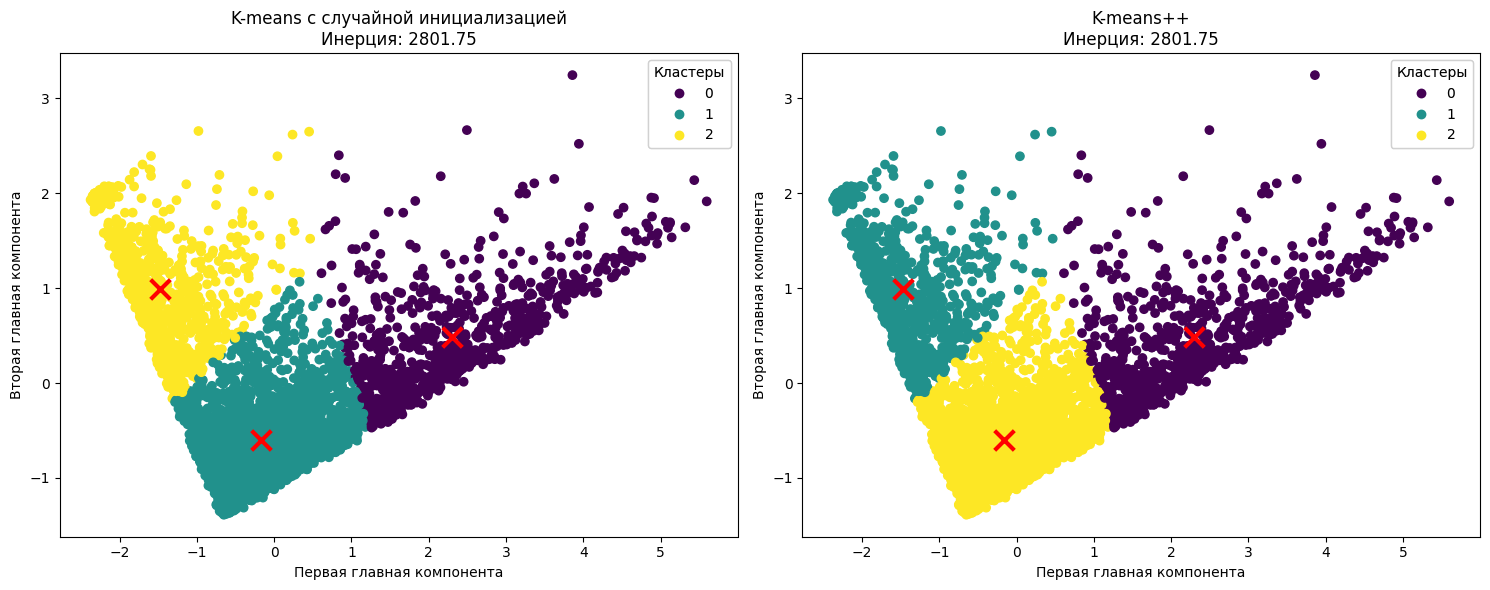

Количество итераций для K-means с случайной инициализацией: 9
Количество итераций для K-means++: 9
Инерция K-means с случайной инициализацией: 2801.75
Инерция K-means++: 2801.75


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(rfm_table_processed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
#K-means с случайной инициализацией
kmeans_random = KMeans(n_clusters=3, init='random', n_init=10, random_state=42)
kmeans_random.fit(rfm_table_processed)
labels_random = kmeans_random.labels_

# K-means++
kmeans_plus = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_plus.fit(rfm_table_processed)
labels_plus = kmeans_plus.labels_

# Визуализация результатов K-means с случайной инициализацией
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_random, cmap='viridis')
ax1.scatter(pca.transform(kmeans_random.cluster_centers_)[:, 0],
           pca.transform(kmeans_random.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax1.set_title('K-means с случайной инициализацией\nИнерция: {:.2f}'.format(kmeans_random.inertia_))
ax1.set_xlabel('Первая главная компонента')
ax1.set_ylabel('Вторая главная компонента')
ax1.legend()

# Визуализация результатов K-means++
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_plus, cmap='viridis')
ax2.scatter(pca.transform(kmeans_plus.cluster_centers_)[:, 0],
           pca.transform(kmeans_plus.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax2.set_title('K-means++\nИнерция: {:.2f}'.format(kmeans_plus.inertia_))
ax2.set_xlabel('Первая главная компонента')
ax2.set_ylabel('Вторая главная компонента')
ax2.legend()

# Добавляем легенду для кластеров
legend1 = ax1.legend(*scatter1.legend_elements(), title="Кластеры", loc="upper right")
ax1.add_artist(legend1)
legend2 = ax2.legend(*scatter2.legend_elements(), title="Кластеры", loc="upper right")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

# Сравнение количества итераций
print(f"Количество итераций для K-means с случайной инициализацией: {kmeans_random.n_iter_}")
print(f"Количество итераций для K-means++: {kmeans_plus.n_iter_}")

# Сравнение инерции (суммы квадратов расстояний до ближайших центров кластеров)
print(f"Инерция K-means с случайной инициализацией: {kmeans_random.inertia_:.2f}")
print(f"Инерция K-means++: {kmeans_plus.inertia_:.2f}")


K_MEANS

Размер каждого кластера:
2    2261
1     972
0     789
Name: count, dtype: int64
В самом большом кластере: 2261 клиентов

AgglomerativeClustering

Размер каждого кластера:
0    2441
2    1120
1     461
Name: count, dtype: int64
В самом большом кластере: 2441 клиентов

DBSCAN

Размер каждого кластера:
0     4021
-1       1
Name: count, dtype: int64
В самом большом кластере: 4021 клиентов


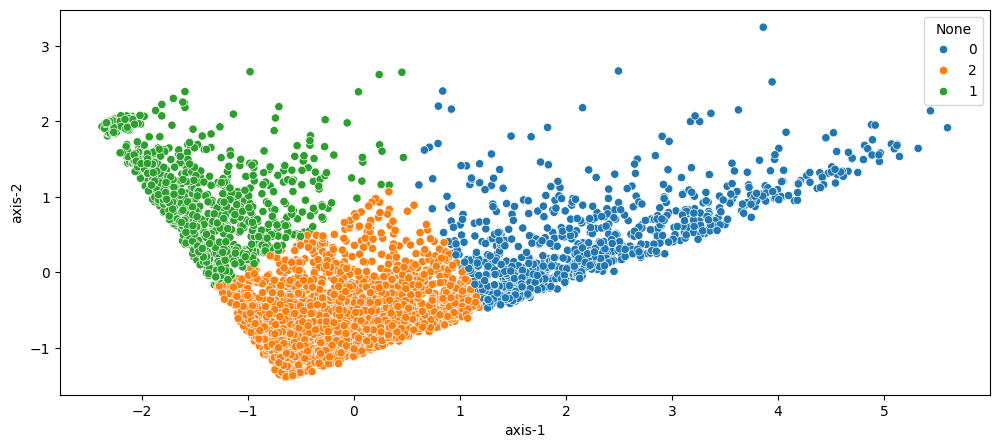

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels_den = pd.Series(hc.labels_.astype("str"), index=rfm_table_processed.index)

# Получаем метки кластеров и преобразуем их в Series, чтобы удобно смотреть размер каждого кластера
labels = pd.Series(model.labels_.astype("str"), index=rfm_table_processed.index)

# Сколько объектов (клиентов) в каждом кластере
print('')
print('K_MEANS')
print('')
cluster_counts = labels.value_counts()
print("Размер каждого кластера:")
print(cluster_counts)

# Определяем, сколько объектов в самом большом кластере
max_cluster_size = cluster_counts.max()
print(f"В самом большом кластере: {max_cluster_size} клиентов")

# Создаём фигуру и ось для графика
fig, ax = plt.subplots(figsize=(12, 5))

# Строим диаграмму рассеяния с раскраской по кластерам
sns.scatterplot(
    data=rfm_table_processed,
    x="axis-1",
    y="axis-2",
    hue=labels,
    ax=ax
)

# Сколько объектов (клиентов) в каждом кластере
print('')
print('AgglomerativeClustering')
print('')
cluster_counts = labels_den.value_counts()
print("Размер каждого кластера:")
print(cluster_counts)

# Определяем, сколько объектов в самом большом кластере
max_cluster_size = cluster_counts.max()
print(f"В самом большом кластере: {max_cluster_size} клиентов")

labels_db = pd.Series(dbscan.labels_.astype("str"), index=rfm_table_processed.index)

# Сколько объектов (клиентов) в каждом кластере
print('')
print('DBSCAN')
print('')
cluster_counts = labels_db.value_counts()
print("Размер каждого кластера:")
print(cluster_counts)

# Определяем, сколько объектов в самом большом кластере
max_cluster_size = cluster_counts.max()
print(f"В самом большом кластере: {max_cluster_size} клиентов")

plt.show()

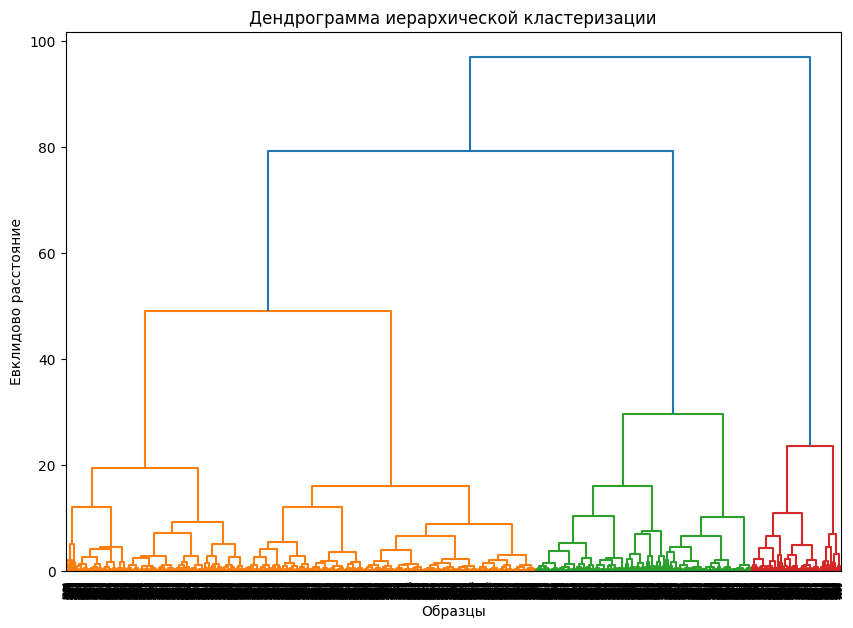

In [ ]:
linked = linkage(rfm_table_processed, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Образцы')
plt.ylabel('Евклидово расстояние')
plt.show()

In [ ]:
rfm_table_processed

,axis-1,axis-2,k-means
Customer ID,,,
12346.0,1.185757,1.186941,0
12347.0,0.324137,-0.856246,2
12348.0,-0.880924,-0.694687,2
12349.0,1.156120,0.075653,0
12351.0,-0.543029,-1.239292,2
...,...,...,...
18283.0,0.810515,-0.562778,2
18284.0,-0.739143,-0.692394,2
18285.0,-1.793425,1.392003,1


/tmp/ipykernel_2202/3177085475.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2202/3177085475.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2202/3177085475.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




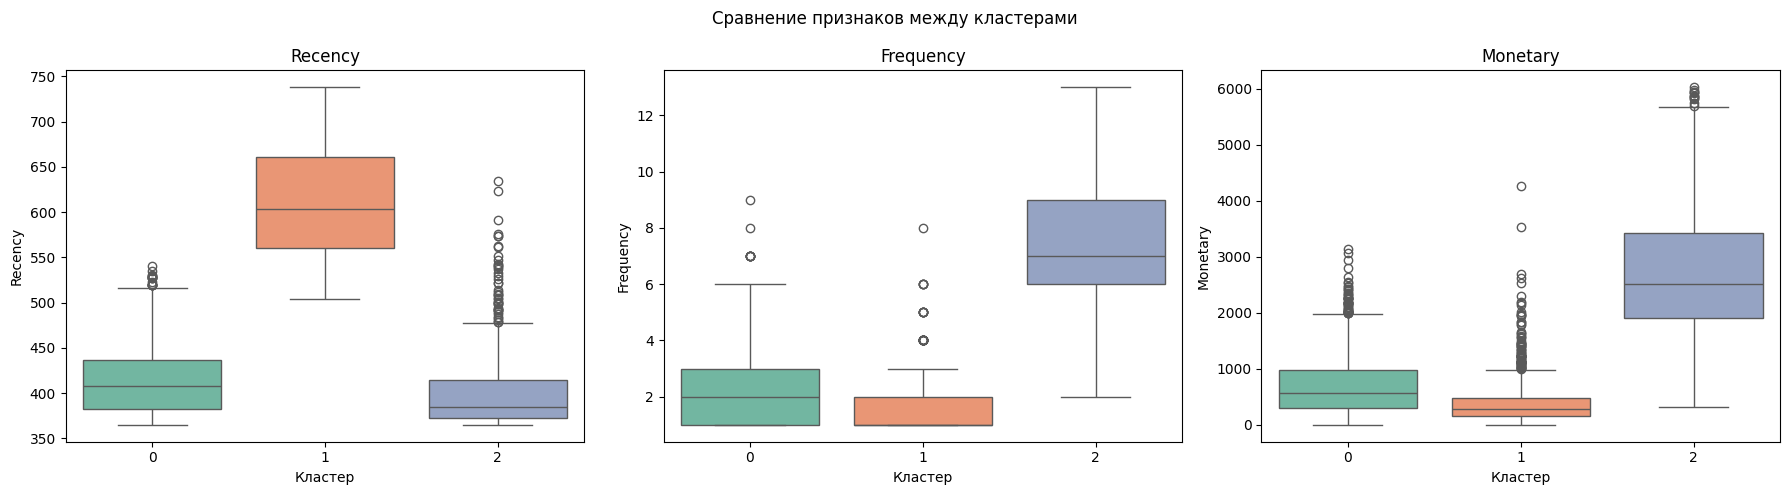

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ["Recency", "Frequency", "Monetary"]
for i, feature in enumerate(features):
    sns.boxplot(x='k-means', y=feature, data=rfm_table_cleaned, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel(feature)
plt.suptitle('Сравнение признаков между кластерами')
plt.tight_layout()
plt.show()

Кластер 0: покупают часто, но мало

Кластер 1: редкие покупатели

Кластер 2: частые покупатели

#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

**Анализ потребностей каждого сегмента**


*   Если исходить из кластеров, можно определить 3 "типа" покупателей по материальному благополучию: кластер 0 описывает людей со среднем достатком, кластер 1 - люди с меньшим достатком, а кластер 2 - люди с относительно большим достатком.


      1.   Кластер 0 предпочитает товары по скидке, так как покупают довольно часто, а также самые часто преобретаемые, тк этот класстер самый многочисленный.
      2.   Кластеру 1 нужны товары первой необходимости и те, что стоят недорого. Возможно это и не люди с малым достатком, но те, кто заходит в данный магазин редко
      3.   Кластер 2 может позволить себе дорогие товары, если покупатель в них заинтересуется


*   Предложения по увеличению прибыли:


      1.   Стоит опираться на кластер 0. Среднестатистический покупатель любит скидки. Стоит вводить скидки на менее популярные товары из средней ценовой категрии.
      2.   Как вариант - вводить больше твоаров, которые заинтересуют кластер. Возможно им будут нравиться уникальные товары.

**Разработка стратегий для каждого сегмента**



*   Можно ввести программу лояльности с бонусами, а можно дать возможность иметь постоянную скидку на "любимые товары".
*   Также можно делать скидки недели на не самые популярные товары, чтобы их охотнее брали

**Оценка потенциального влияния**



*   Данная стратегия повысит интерес покупателей к магазину (лояльность к клиентам), а также можно будет лучше продавать не очень популярные товары



#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Цель работы:
    Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.
  - Значимость для бизнеса: Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.
- **Методология:**
  1. Сбор и первичный анализ данных (EDA)
  2. Предобработка данных:

      - Удаление строки с отсутствующими идентификаторами клиентов
      - Удаление записей с нулевыми или отрицательными ценами
      - Удаление полных дубликатов записей
      - RFM-анализ
      - Нормализация и снижение размерности
  3. Применение алгоритмов кластеризации (Kmeans, DBSCAN, иерархическая)
  4. Оценка качества кластеризации
- **Результаты:**
  - Кластер 0: Экономные и частые покупатели. Это самый многочисленный сегмент (2261 клиент). Они имеют среднюю частоту покупок и среднюю денежную ценность.
  - Кластер 1: Новые или угасающие покупатели. Второй по величине сегмент (972 клиента). У них самая высокая давность последней покупки (давно не покупали), самая низкая частота и самая низкая денежная ценность.
  - Кластер 2: Самые ценные покупатели(вип клиенты). Этот сегмент самый малочисленный (789 клиентов). У них самая низкая давность последней покупки (покупали недавно), самая высокая частота и самая высокая денежная ценность.
- **Обсуждение:**
  - K-means оказался лучшим. DBSCAN не делил данные на кластеры, но выявил шумы.
- **Рекомендации:**
  - Проводить акции "2+1 в подарок" для стимулирования увеличения чека.
  - Предоставлять персональные скидки и специальные предложения на основе истории покупок.
  - Предложить скидку на следующий заказ с ограниченным сроком действия.
- **Заключение:**
  - В ходе работы была разработана система сегментации клиентов на основе RFM-анализа. Наилучший результат показал алгоритм K-Means, выделивший три четких сегмента: VIP-клиенты (покупают часто и дорого), основные покупатели (самая многочисленная группа со средними показателями) и новые или угасающие клиенты (покупают редко и дёшево). Для каждого сегмента предложены целевые маркетинговые стратегии: для VIP-клиентов — программы лояльности и удержания, для основной группы — стимулирование роста чека и частоты покупок, для угасающих — реактивация через скидки и промокоды. Внедрение этих рекомендаций позволит компании повысить лояльность клиентов, оптимизировать маркетинговые расходы и увеличить прибыль, что подтверждает практическую ценность методов кластеризации для розничного бизнеса.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.

